<a href="https://colab.research.google.com/github/Destinywaya9/QCC-Bench/blob/main/Pauli.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 3.4 MB/s eta 0:00:00


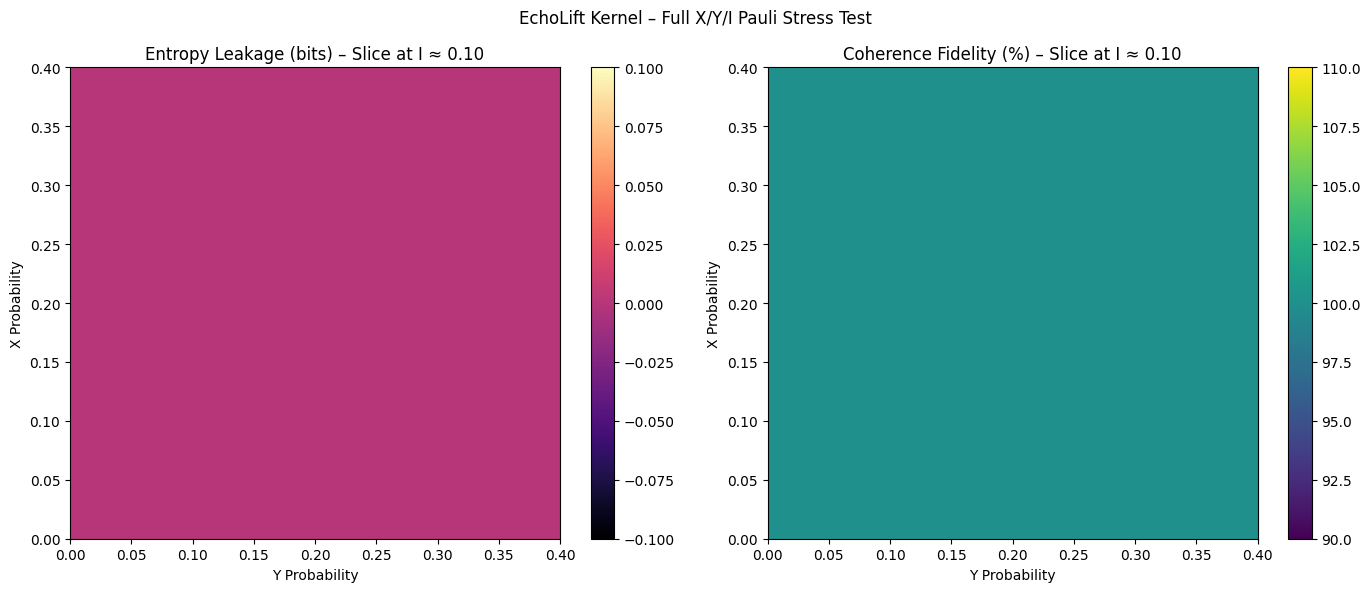

In [1]:
# --- Setup ---
!pip install qiskit qiskit-aer matplotlib --quiet

# --- Imports ---
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, pauli_error

# --- QCC Echo Kernel ---
def build_kernel():
    qc = QuantumCircuit(3, 3)
    qc.h(0)
    qc.cx(0, 1)
    qc.cx(1, 2)
    qc.cx(1, 2)
    qc.cx(0, 1)
    qc.h(0)
    qc.barrier()
    qc.delay(200, 0, 'ns')
    qc.delay(200, 1, 'ns')
    qc.delay(200, 2, 'ns')
    qc.measure([0, 1, 2], [0, 1, 2])
    return qc

def compute_entropy_and_fidelity(counts):
    probs = np.array(list(counts.values())) / sum(counts.values())
    entropy = -np.sum([p * np.log2(p) for p in probs if p > 0])
    fidelity = max(probs) * 100
    return entropy, fidelity

# --- Sweep Values ---
x_vals = np.linspace(0.0, 0.4, 9)
y_vals = np.linspace(0.0, 0.4, 9)
i_vals = np.linspace(0.0, 0.4, 9)

# --- Allocate Result Storage ---
entropy_map = np.zeros((len(x_vals), len(y_vals), len(i_vals)))
fidelity_map = np.zeros((len(x_vals), len(y_vals), len(i_vals)))

# --- Full 3D Sweep Over X, Y, I ---
for i, x in enumerate(x_vals):
    for j, y in enumerate(y_vals):
        for k, i_prob in enumerate(i_vals):
            total = x + y + i_prob
            if total > 1.0:
                # Normalize to sum to 1.0 if overflow
                x_n = x / total
                y_n = y / total
                i_n = i_prob / total
            else:
                x_n = x
                y_n = y
                i_n = 1.0 - (x + y)  # Automatically adjust I if room

            # Build Noise Model
            error_1q = pauli_error([('X', x_n), ('Y', y_n), ('I', i_n)])
            error_2q = error_1q.tensor(error_1q)
            noise_model = NoiseModel()
            noise_model.add_all_qubit_quantum_error(error_2q, ['cx'])

            # Simulate
            qc = build_kernel()
            sim = AerSimulator(noise_model=noise_model)
            result = sim.run(transpile(qc, sim), shots=8192).result()
            counts = result.get_counts()
            entropy, fidelity = compute_entropy_and_fidelity(counts)

            entropy_map[i, j, k] = entropy
            fidelity_map[i, j, k] = fidelity

# --- Plot: Choose a slice at a fixed I level ---
i_index = 2  # Choose I ≈ 0.1 (adjustable)
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

im1 = axs[0].imshow(entropy_map[:, :, i_index], origin='lower',
                    extent=[0, 0.4, 0, 0.4], aspect='auto', cmap='magma')
axs[0].set_title("Entropy Leakage (bits) – Slice at I ≈ {:.2f}".format(i_vals[i_index]))
axs[0].set_xlabel("Y Probability")
axs[0].set_ylabel("X Probability")
fig.colorbar(im1, ax=axs[0])

im2 = axs[1].imshow(fidelity_map[:, :, i_index], origin='lower',
                    extent=[0, 0.4, 0, 0.4], aspect='auto', cmap='viridis')
axs[1].set_title("Coherence Fidelity (%) – Slice at I ≈ {:.2f}".format(i_vals[i_index]))
axs[1].set_xlabel("Y Probability")
axs[1].set_ylabel("X Probability")
fig.colorbar(im2, ax=axs[1])

plt.suptitle("EchoLift Kernel – Full X/Y/I Pauli Stress Test")
plt.tight_layout()
plt.show()

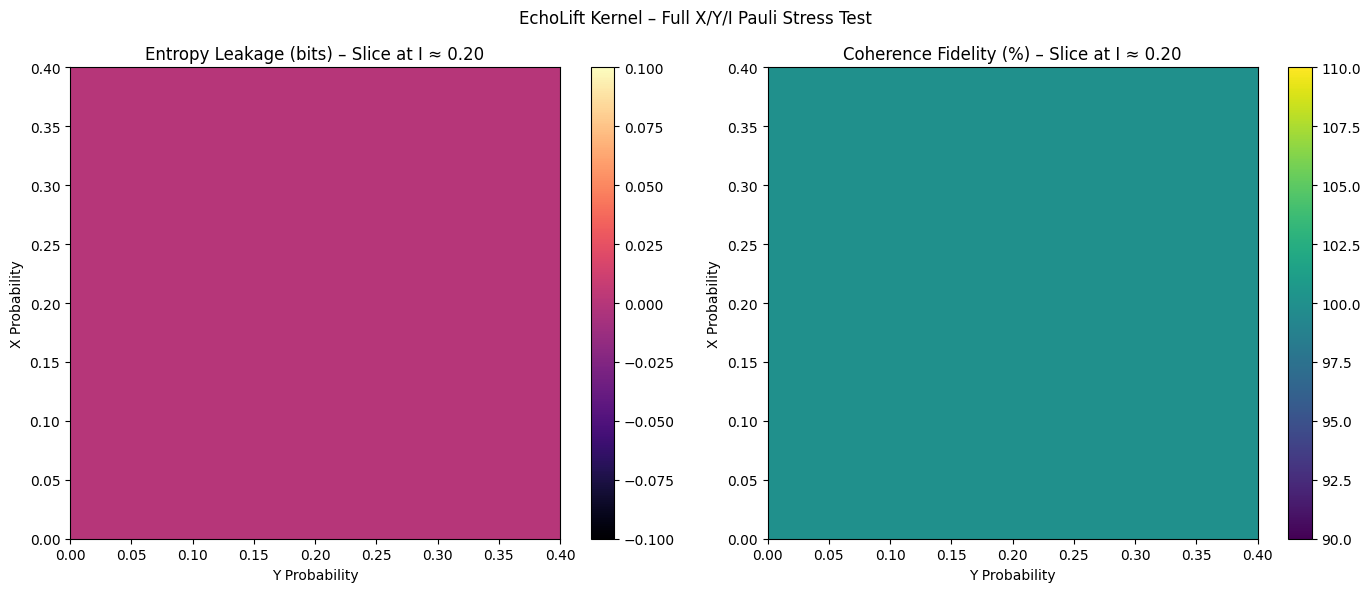

In [2]:
# --- Setup ---
!pip install qiskit qiskit-aer matplotlib --quiet

# --- Imports ---
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, pauli_error

# --- QCC Echo Kernel ---
def build_kernel():
    qc = QuantumCircuit(3, 3)
    qc.h(0)
    qc.cx(0, 1)
    qc.cx(1, 2)
    qc.cx(1, 2)
    qc.cx(0, 1)
    qc.h(0)
    qc.barrier()
    qc.delay(200, 0, 'ns')
    qc.delay(200, 1, 'ns')
    qc.delay(200, 2, 'ns')
    qc.measure([0, 1, 2], [0, 1, 2])
    return qc

def compute_entropy_and_fidelity(counts):
    probs = np.array(list(counts.values())) / sum(counts.values())
    entropy = -np.sum([p * np.log2(p) for p in probs if p > 0])
    fidelity = max(probs) * 100
    return entropy, fidelity

# --- Sweep Values ---
x_vals = np.linspace(0.3, 0.9, 7)
y_vals = np.linspace(0.3, 0.9, 7)
i_vals = np.linspace(0.0, 0.4, 5)

# --- Allocate Result Storage ---
entropy_map = np.zeros((len(x_vals), len(y_vals), len(i_vals)))
fidelity_map = np.zeros((len(x_vals), len(y_vals), len(i_vals)))

# --- Full 3D Sweep Over X, Y, I ---
for i, x in enumerate(x_vals):
    for j, y in enumerate(y_vals):
        for k, i_prob in enumerate(i_vals):
            total = x + y + i_prob
            if total > 1.0:
                # Normalize to sum to 1.0 if overflow
                x_n = x / total
                y_n = y / total
                i_n = i_prob / total
            else:
                x_n = x
                y_n = y
                i_n = 1.0 - (x + y)  # Automatically adjust I if room

            # Build Noise Model
            error_1q = pauli_error([('X', x_n), ('Y', y_n), ('I', i_n)])
            error_2q = error_1q.tensor(error_1q)
            noise_model = NoiseModel()
            noise_model.add_all_qubit_quantum_error(error_2q, ['cx'])

            # Simulate
            qc = build_kernel()
            sim = AerSimulator(noise_model=noise_model)
            result = sim.run(transpile(qc, sim), shots=8192).result()
            counts = result.get_counts()
            entropy, fidelity = compute_entropy_and_fidelity(counts)

            entropy_map[i, j, k] = entropy
            fidelity_map[i, j, k] = fidelity

# --- Plot: Choose a slice at a fixed I level ---
i_index = 2  # Choose I ≈ 0.1 (adjustable)
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

im1 = axs[0].imshow(entropy_map[:, :, i_index], origin='lower',
                    extent=[0, 0.4, 0, 0.4], aspect='auto', cmap='magma')
axs[0].set_title("Entropy Leakage (bits) – Slice at I ≈ {:.2f}".format(i_vals[i_index]))
axs[0].set_xlabel("Y Probability")
axs[0].set_ylabel("X Probability")
fig.colorbar(im1, ax=axs[0])

im2 = axs[1].imshow(fidelity_map[:, :, i_index], origin='lower',
                    extent=[0, 0.4, 0, 0.4], aspect='auto', cmap='viridis')
axs[1].set_title("Coherence Fidelity (%) – Slice at I ≈ {:.2f}".format(i_vals[i_index]))
axs[1].set_xlabel("Y Probability")
axs[1].set_ylabel("X Probability")
fig.colorbar(im2, ax=axs[1])

plt.suptitle("EchoLift Kernel – Full X/Y/I Pauli Stress Test")
plt.tight_layout()
plt.show()